In [2]:
student_name = "Amosco"         
student_id   = "TUPM-25-1206"          
 
id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
 
print(f"color1 = {color1}  |  color2 = {color2}")

color1 = #a26a06  |  color2 = #9c3e38


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
 
student_name = "Amosco"
student_id = "TUPM-25-1206"
id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) 
% 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) 
% 256:02x}"

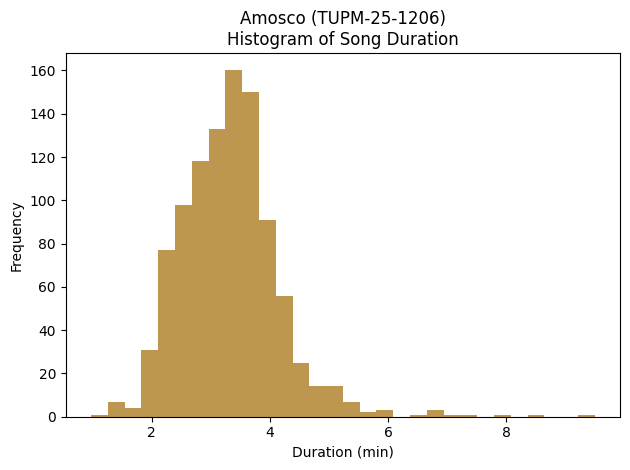

In [6]:
# 01
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\Lenovo\\Downloads\\spotify_top_1000_tracks.csv")

df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10040\1178012275.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


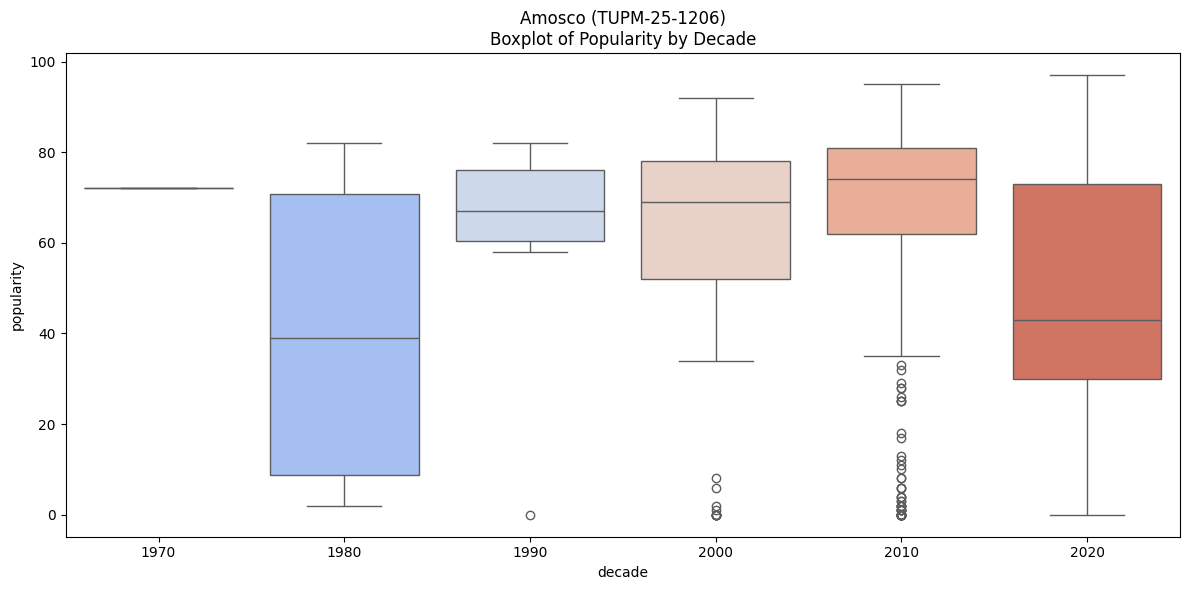

In [10]:
#02
import seaborn as sns

df['release_year'] = pd.to_datetime(df['release_date'], format='mixed').dt.year
df['decade'] = (df['release_year'] // 10) * 10
plt.figure(figsize=(12, 6))
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10040\3142564471.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


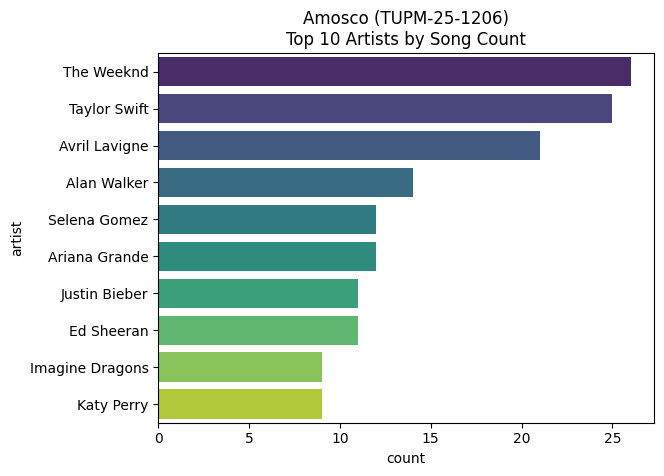

In [ ]:
#03

sns.countplot(y='artist', data=df, 
order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10040\4149843195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


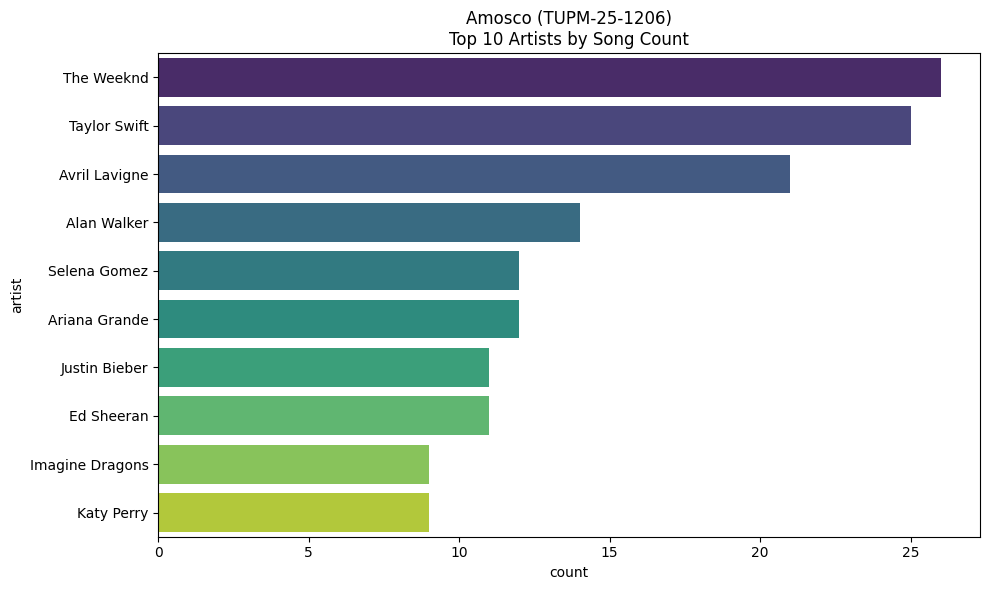

In [ ]:
#03

plt.figure(figsize=(10, 6))
sns.countplot(
    y='artist', data=df,
    order=df['artist'].value_counts().head(10).index,
    palette='viridis'
)
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10040\51457209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade',


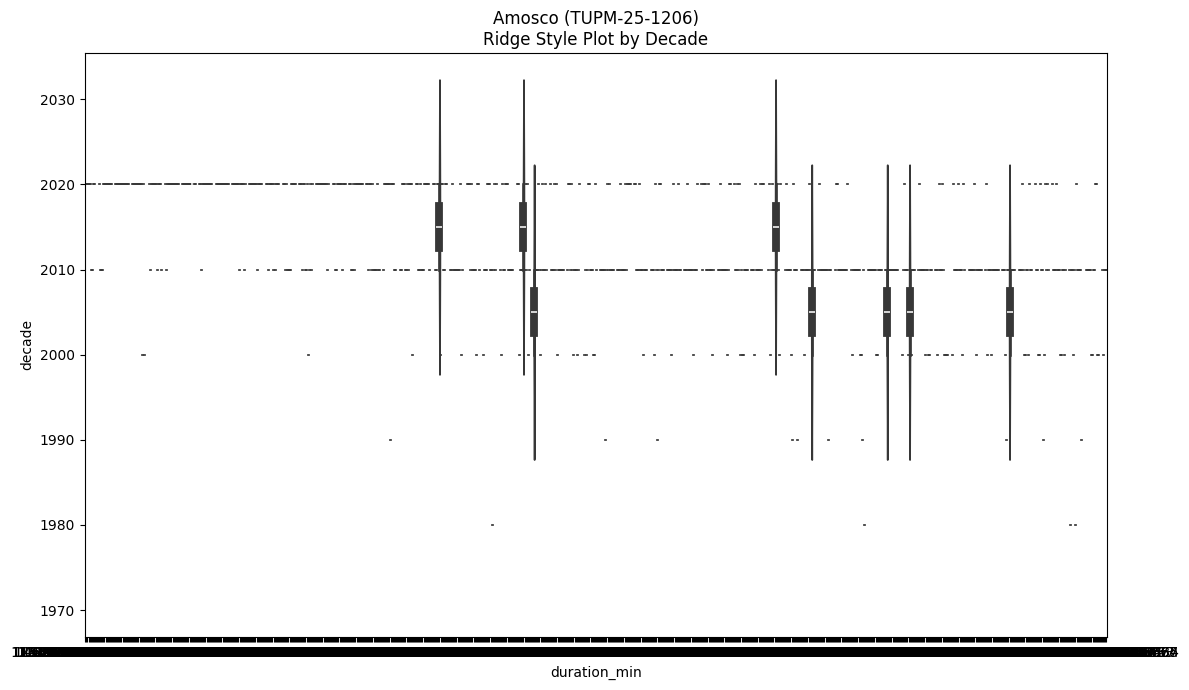

In [19]:
#04

plt.figure(figsize=(12, 7))
try:
    sns.violinplot(data=df, x='duration_min', y='decade',
                   palette='coolwarm', density_norm='width')
except TypeError:
    # Seaborn < 0.13 fallback
    sns.violinplot(data=df, x='duration_min', y='decade',
                   palette='coolwarm', scale='width')
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.tight_layout()
plt.show()

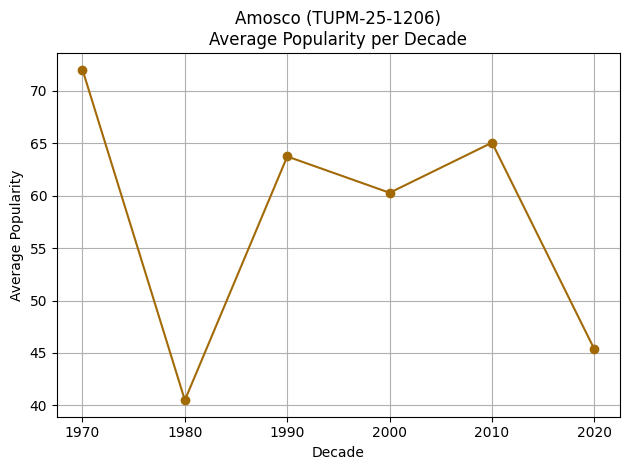

In [20]:
#05

avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color=color1, marker='o')
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.tight_layout()
plt.show()

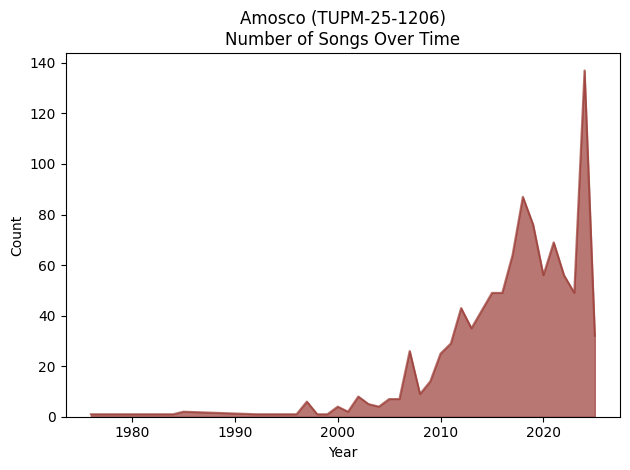

In [ ]:
#06

count_by_year = df['release_year'].value_counts().sort_index()
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

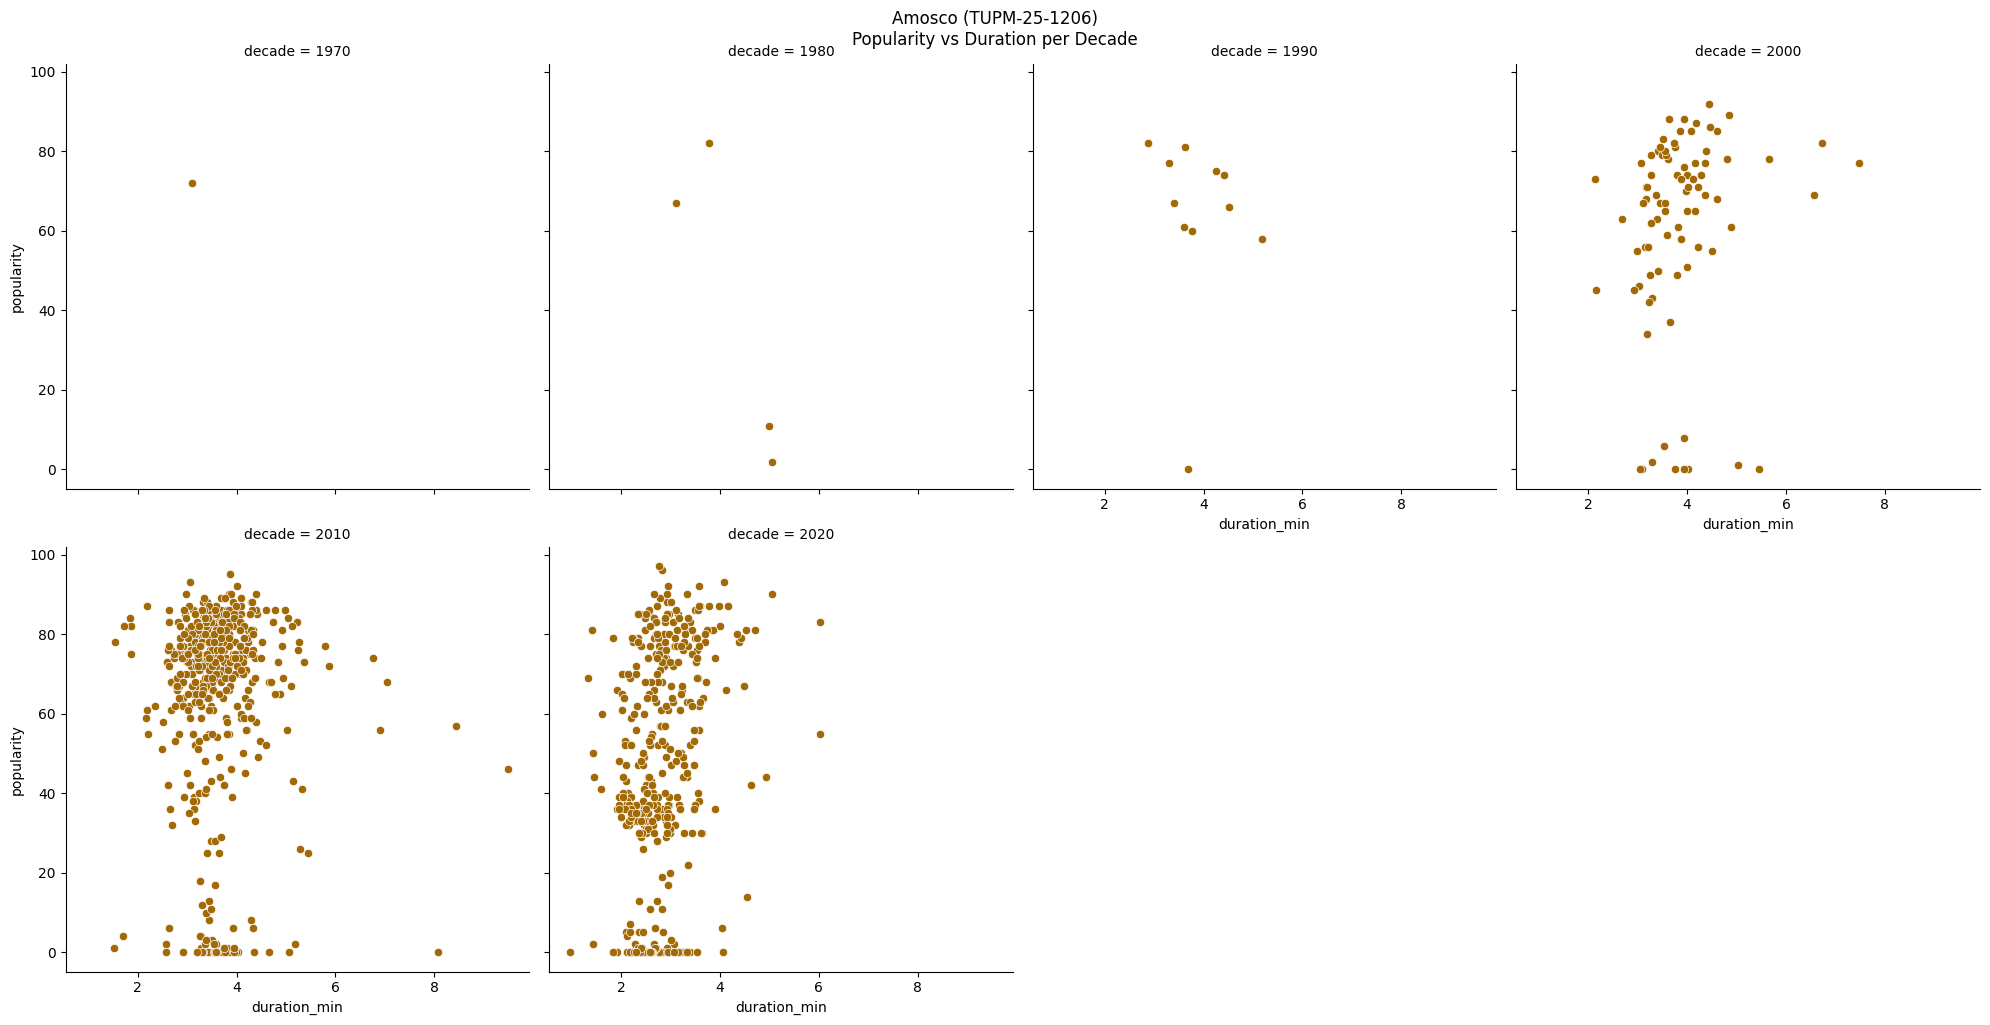

In [23]:
#07

g = sns.FacetGrid(df, col='decade', col_wrap=4, height=5)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color=color1)
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02)
plt.show()

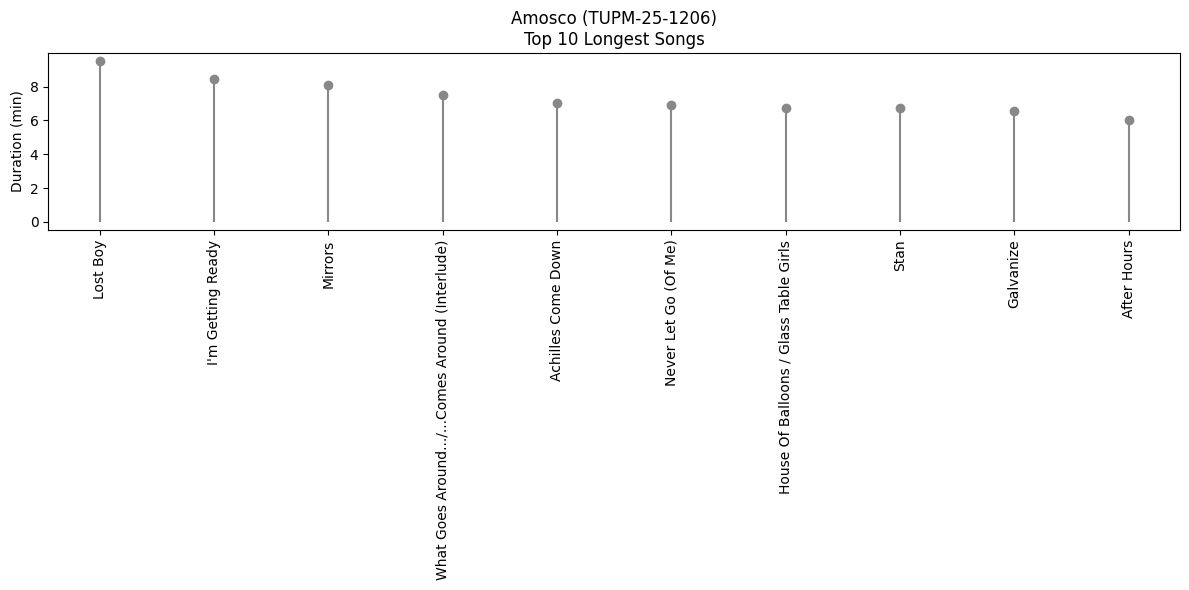

In [25]:
#08

longest = df.nlargest(10, 'duration_min')
plt.figure(figsize=(12, 6))
plt.stem(longest['track_name'], longest['duration_min'],
         linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

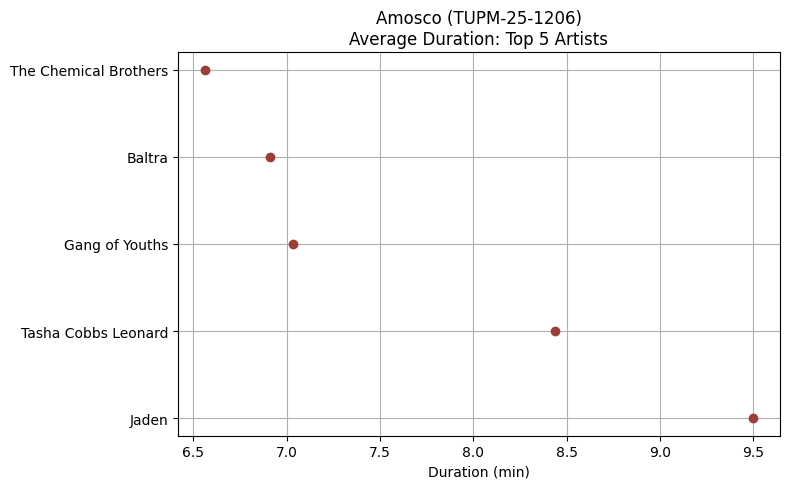

In [27]:
#09

avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.figure(figsize=(8, 5))
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

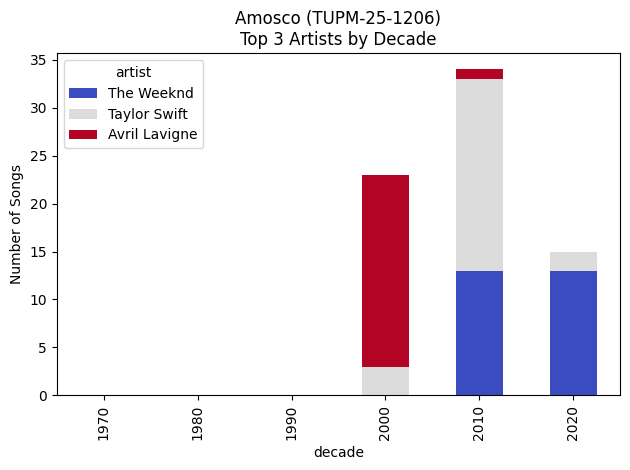

In [28]:
#10

crosstab = pd.crosstab(df['decade'], df['artist'])
top3 = df['artist'].value_counts().head(3).index
plt.figure(figsize=(10, 6))
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

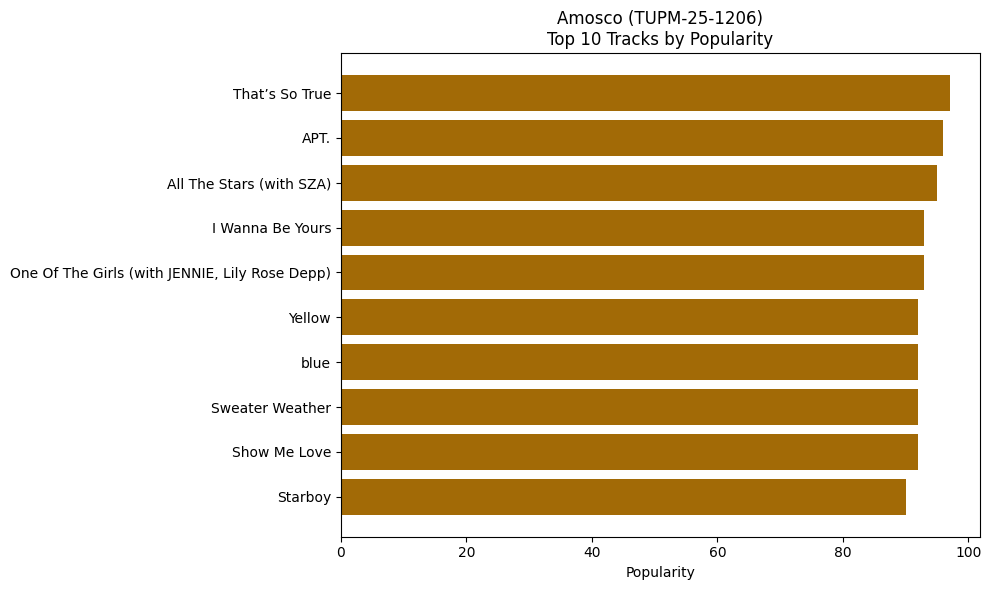

In [29]:
#11
top_tracks = df.nlargest(10, 'popularity')
plt.figure(figsize=(10, 6))
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10040\278904606.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


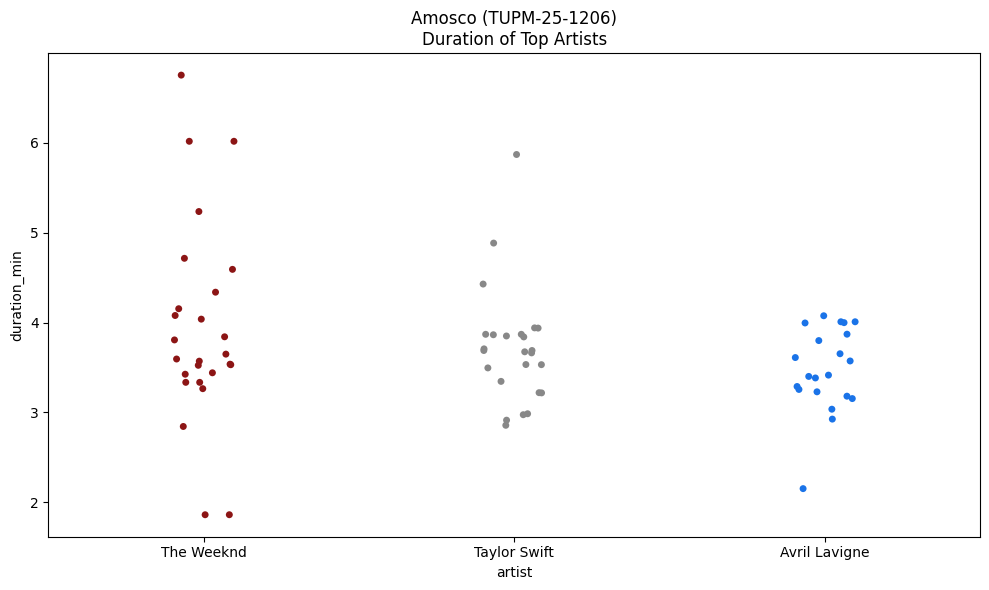

In [30]:
#12

top_artists = df['artist'].value_counts().head(3).index
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=df[df['artist'].isin(top_artists)],
    x='artist', y='duration_min',
    palette=['#8C1515', '#888888', '#1A73E8']  # FIX: 3 colors for 3 artists
)
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.tight_layout()
plt.show()

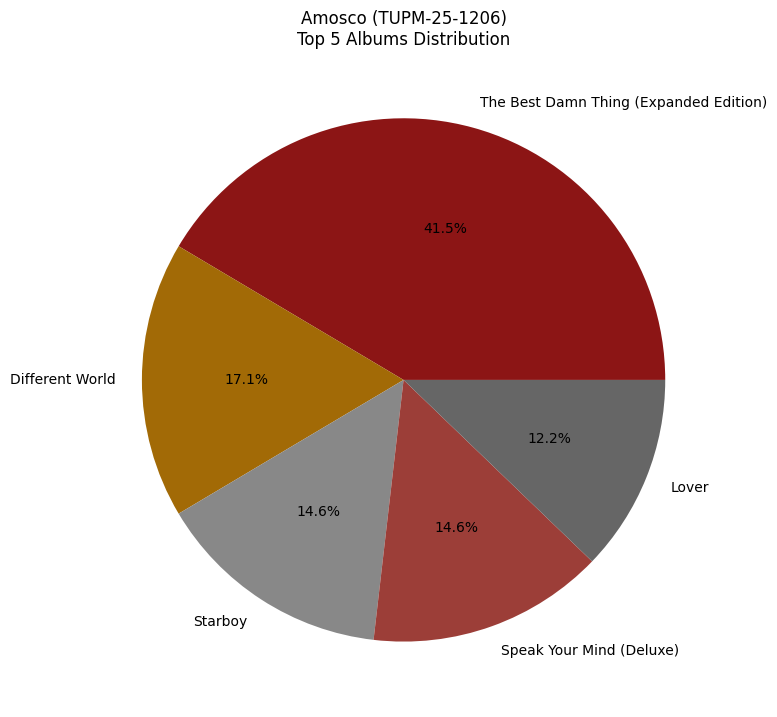

In [31]:
#13

top_albums = df['album'].value_counts().head(5)
colors_pie = ['#8C1515', color1, '#888888', color2, '#666666']
plt.figure(figsize=(8, 8))
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors_pie)
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.tight_layout()
plt.show()

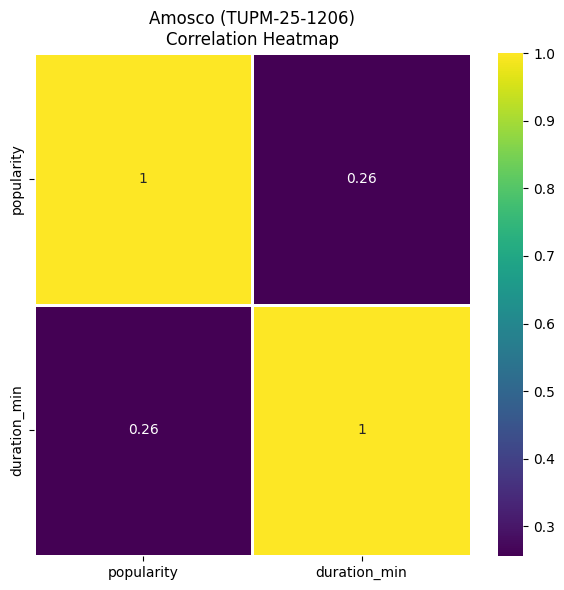

In [9]:
#14

import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
df = pd.read_csv("C:\\Users\\Lenovo\\Downloads\\spotify_top_1000_tracks.csv")

numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()
plt.figure(figsize=(6, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='viridis', linewidths=0.75)
plt.title(f"{student_name} ({student_id})\nCorrelation Heatmap")
plt.tight_layout()
plt.show()



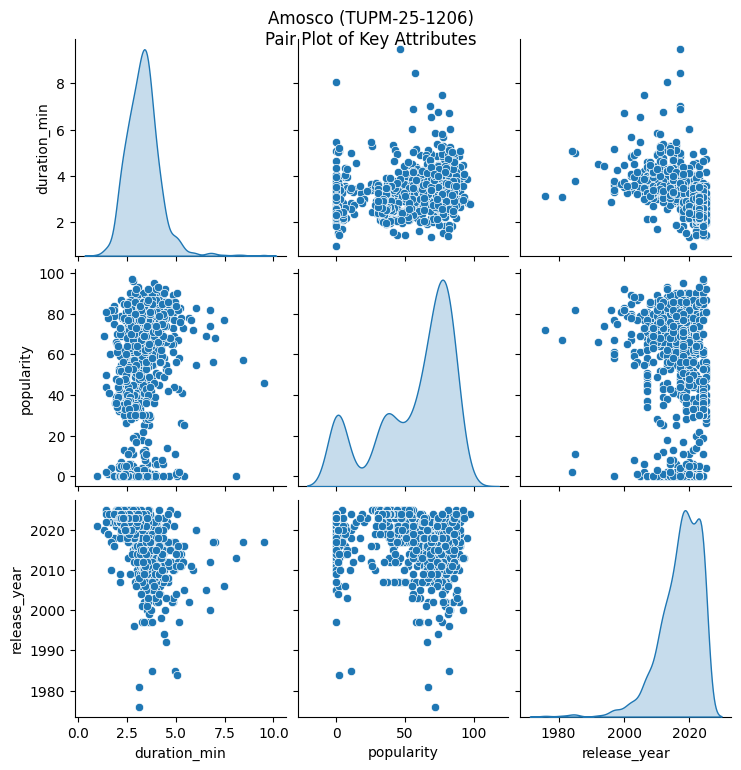

In [15]:
#15

df['release_year'] = pd.to_datetime(df['release_date'], format='mixed').dt.year
sns.pairplot(df[['duration_min', 'popularity', 'release_year']], diag_kind='kde')
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02)
plt.show()

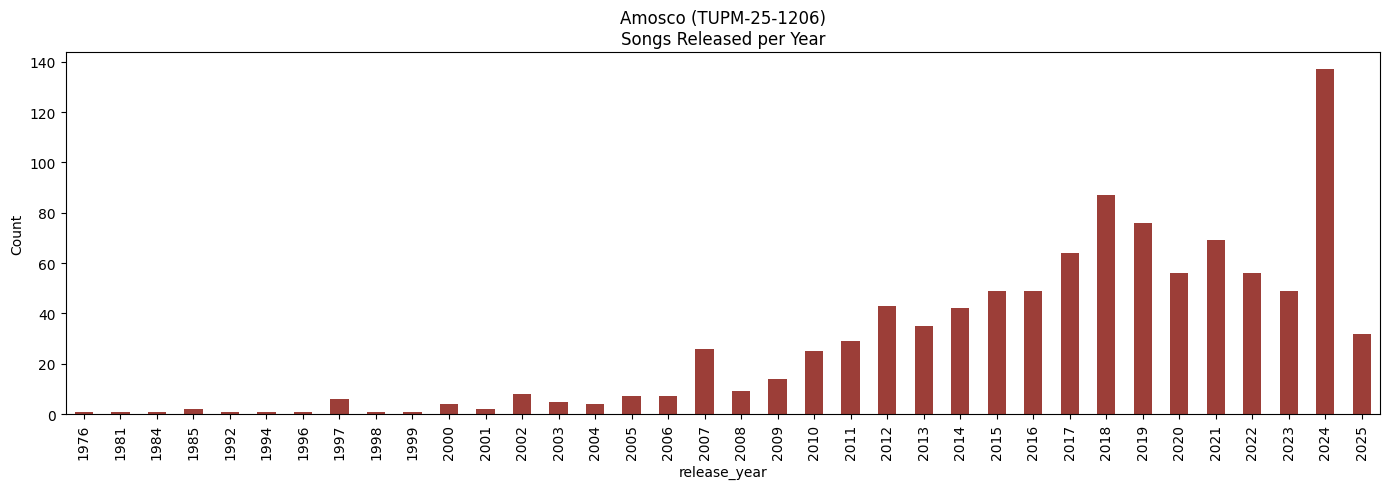

In [16]:
#16

plt.figure(figsize=(14, 5))
df['release_year'].value_counts().sort_index().plot(kind='bar', color=color2)
plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9936\3408750401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


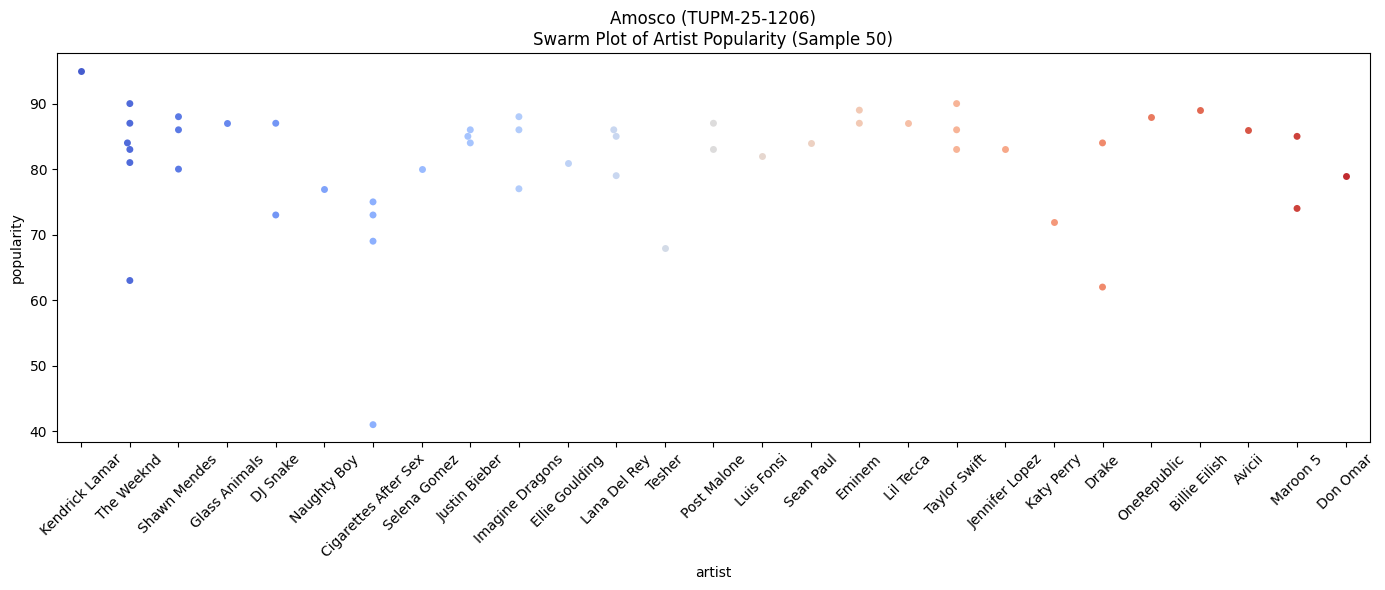

In [17]:
#17

plt.figure(figsize=(14, 6))
sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

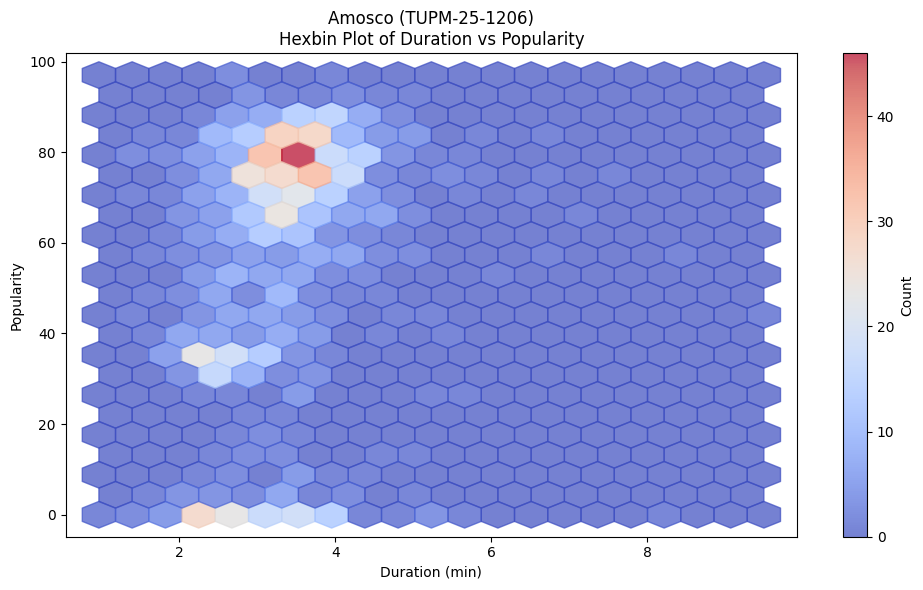

In [18]:
#18

plt.figure(figsize=(10, 6))
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Count')
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")
plt.tight_layout()
plt.show()

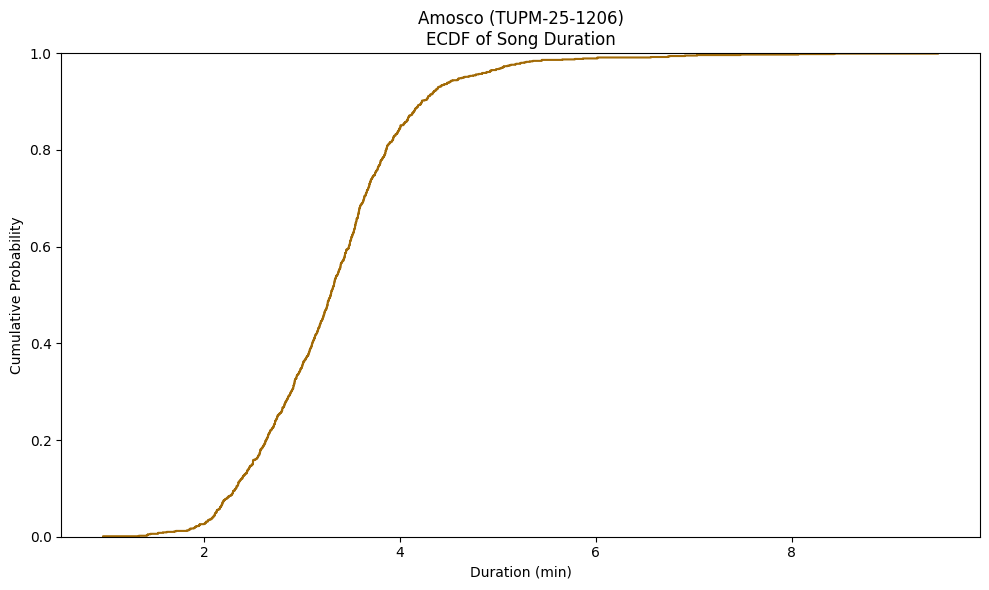

In [19]:
#19

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df, x='duration_min', color=color1)
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.tight_layout()
plt.show()

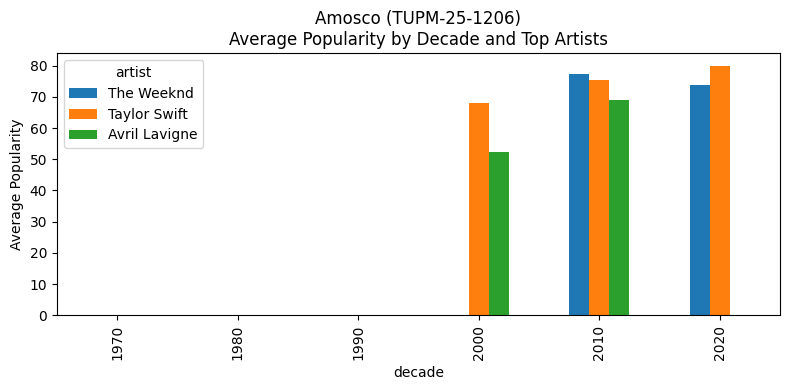

In [21]:
#20

df['release_year'] = pd.to_datetime(df['release_date'], format='mixed').dt.year
df['decade'] = (df['release_year'] // 10) * 10
top3 = df['artist'].value_counts().head(3).index

avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4))
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')
plt.tight_layout()
plt.show()